# Wound Edge estimation

In this demo we will show how to perform the estimation of the wound edge, starting from a 2D image and a depth map.
In this context we are not particularly focused on the correct transformation and measurement of depth in standard unit of measurements, while we are more interested in the characterization of the wound edges in terms comparable with the standard BWAT and PWAT scales.
This analysis relies on the availability of a good segmentation model for the wound identification and on the possibility to estimate an accurate depth map.
For the development of the required segmentation model, we refer to the [deepskin_assl](https://github.com/Nico-Curti/blob/main/docs/sources/notebooks/deepskin_assl.ipynb) demo of the `deepskin` package.
For the estimation of the depth map, we refer to the results obtained using the [ZoeDepth](https://github.com/isl-org/ZoeDepth) model.

In this demo, we will use the functions proposed in `deepskin` package for the analysis of the image and the edge estimation.
For sake of clarity, we will show how to implement the code that is used inside the `shape_edge` function of the package and how to visualize the intermediate steps related to the correct characterization of the wound edges.

First of all we need to load the 2D image.

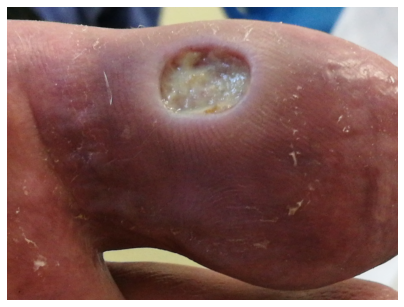

In [1]:
import cv2
import pylab as plt

# define the image filename
filename = 'image_edge.png'
# load the image using OpenCV library
img = cv2.imread(filename)
# convert the image to RGB fmt for the display
img = img[..., ::-1]

# define the plot figure
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 7))
canvas = ax.imshow(img)
_ = ax.axis('off')

The next step involves the estimation of the semantic segmentation mask, in which we can automatically identify the ROI of the wound and body.
To this purpose we will use the updated version of the model stored in the `deepskin` package.

Perform the semantic image segmentation...  [DONE] (12.423 sec)                  


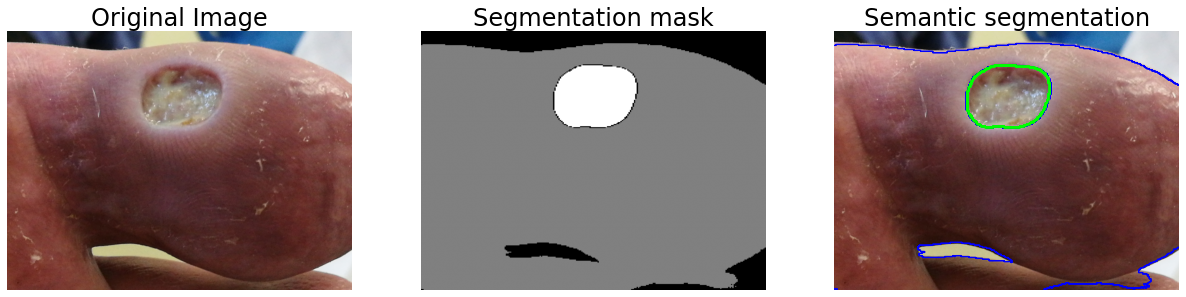

In [2]:
import cv2
import numpy as np
from deepskin import wound_segmentation

# get the wound segmentation mask
segmentation = wound_segmentation(
  img=img,
  tol=0.95,
  verbose=True,
)

bg_mask, body_mask, marker_mask, wound_mask = cv2.split(segmentation)
semantic_seg = np.where(body_mask != 0, 128, 0) | wound_mask | np.where(marker_mask != 0, 192, 0)

# display the results
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(21, 7))
ax1.imshow(img)
ax1.set_title('Original Image', fontsize=24)
_ = ax1.axis('off')
ax2.imshow(semantic_seg, cmap='gray')
ax2.set_title('Segmentation mask', fontsize=24)
_ = ax2.axis('off')
ax3.imshow(img)
ax3.contour(body_mask, colors='blue', linewidths=1)
ax3.contour(wound_mask, colors='lime', linewidths=2)
ax3.contour(marker_mask, colors='gold', linewidths=2)
ax3.set_title('Semantic segmentation', fontsize=24)
_ = ax3.axis('off')

Now we will show how to get the entire visualization of the wound edges, starting from the depth-map.
Since our implementation is independent by the model used for this step, we simply load a pre-defined depth map that in the current case was generated using the ZoeDepth model.

**⚠️ Note:** A depth map typically stores the information with a precision higher than the classical `uint8`, so pay attention to load it correctly, setting the `IMREAD_ANYDEPTH` keyword in the call.

The results of the following code are already implemented into the `shape_edge` function: we manually re-implement also the intermediate steps required as pre-processing to better clarify the ideas behind this processing.

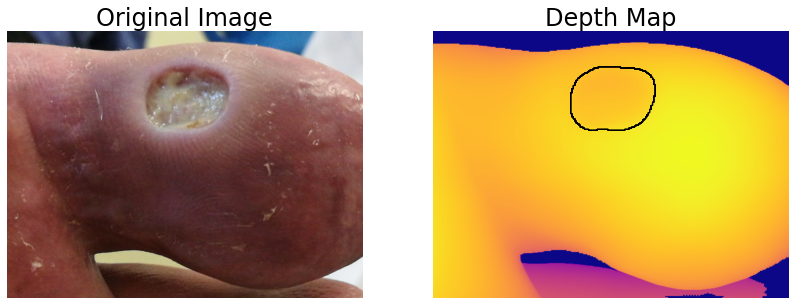

In [3]:
depth_map = cv2.imread('depth_map_edge.png', cv2.IMREAD_ANYDEPTH)

if not marker_mask is None:
  depth_map = cv2.bitwise_and(depth_map, depth_map, mask=~marker_mask)
  #body_mask = cv2.bitwise_and(body_mask, body_mask, mask=~marker_mask)

# exclude the background and focus the analysis on the body mask
depth_map = cv2.bitwise_and(depth_map, depth_map, mask=~bg_mask)

# compute the Z-score of the depth map
score = (depth_map - depth_map.mean()) / depth_map.std()
# safety copy of the body mask
body_corrected = body_mask | wound_mask | marker_mask
# correct the body mask according to the threshold of Z-score
body_corrected[(score < -2) | (score > 2)] = 0
# re-mask the depth map according to the new body mask
depth_component = cv2.bitwise_and(
  depth_map, depth_map, 
  mask=body_corrected
)

# display the results
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))
ax1.imshow(img)
ax1.set_title('Original Image', fontsize=24)
_ = ax1.axis('off')
ax2.imshow(depth_map, cmap='plasma')
ax2.set_title('Depth Map', fontsize=24)
ax2.contour(wound_mask, colors='k', linewidths=1)
ax2.contour(marker_mask, colors='k', linewidths=1)
_ = ax2.axis('off')

In this example we can clearly notice that the wound surface is not exactly vertical in the FOV.
This effect could produce misleading characterization of the wound edges, mainly due to the body orientation.

Therefore, a preliminar step could involve the correction of the body orientation according to a rough geometrical transformation as given by the following code.

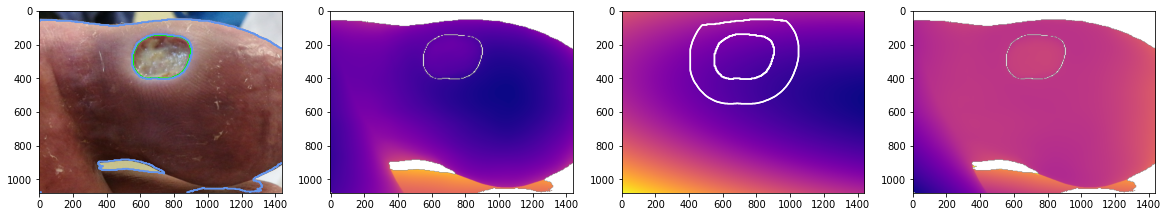

In [4]:
from scipy.optimize import curve_fit

def func(xy, a, b, c, d, e, f): 
  x, y = xy 
  return a + b*x + c*y + d*x**2 + e*y**2 + f*x*y

# dilate the wound to keep track of a smarter ROI
# just around the wound shape
kernel = cv2.getStructuringElement(
  shape=cv2.MORPH_ELLIPSE, 
  ksize=(300, 300)
)
dilated_wound = cv2.dilate(
  wound_mask, 
  kernel=kernel, 
  iterations=1
)
# remove the wound to get only the body
# components around the wound
# NOTE: in this way we can preserve the internal
# curvature of the wound shape
dilated_wound = dilated_wound - wound_mask
# re-mask the wound using the body mask
# to discard useless points
# NOTE: the dilation could go outside the
# body if the wound are close to a boundary
dilated_wound = cv2.bitwise_and(
  dilated_wound, dilated_wound, 
  mask=body_corrected
)

# select the points of the depth map associated
# to this new mask, putting every other point
# to zero for a fast filtering
depth_body_no_wound = np.where(
  dilated_wound == 0, 
  0, depth_component
)
# get the coordinates for the fit
x, y = np.nonzero(depth_body_no_wound)
# select the z coordinates to fit
z = depth_body_no_wound[depth_body_no_wound != 0]

# perform curve fitting 
popt, pcov = curve_fit(
  f=func, 
  xdata=(x, y), 
  ydata=z
)

# create a new grid for the curvature correction
h, w = depth_component.shape
y, x = np.mgrid[0:h, 0:w]
# use the parameters to get the curvature fit
z = func((y, x), *popt)

# correct the depth map removing the curvature
depth_corrected = depth_component - z
# re-apply the body mask
depth_corrected = cv2.bitwise_and(
  depth_corrected, depth_corrected, 
  mask=body_mask | wound_mask
)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
ax1.imshow(img)
ax1.contour(wound_mask, levels=1, colors='lime')
ax1.contour(body_mask, levels=1, colors='cornflowerblue')
ax2.imshow(np.where(depth_component != 0, depth_component, np.nan), cmap='plasma_r')
ax3.imshow(z, cmap='plasma_r')
ax3.contour(dilated_wound, levels=1, colors='w')
ax4.imshow(np.where(depth_corrected != 0, depth_corrected, np.nan), cmap='plasma_r')

The next step is where the real magic happens!
To perform the monitoring of the wound edges, the trick is to build a rectified version of the perilesion area, i.e. unrolling the closed shape around the wound into an image.
Applying this procedure on both the image and (corrected) depth-map, we can provide a parallelism between the wound edges and the corresponding 3D reconstruction.

The following code use the `deepskin` functions to show this effect.

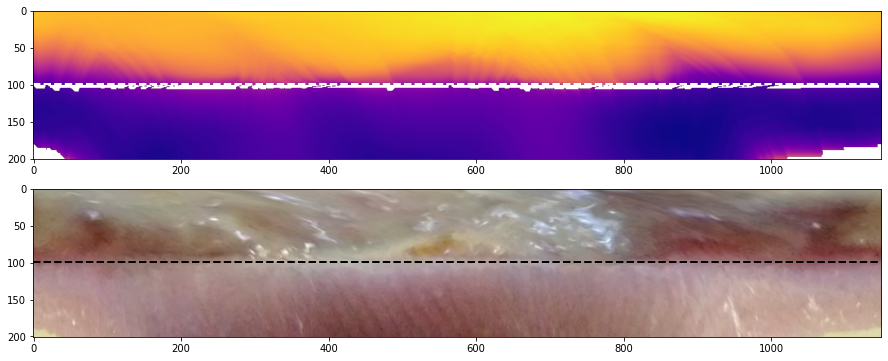

In [5]:
from deepskin.imgproc import rectify_boundary_mask

# maximum number of concentric shapes to evaluate inside/outside the wound
iterations = 100

# image rectification of the depth-map
rectify_depth, (s1, s2) = rectify_boundary_mask(
  # filter only valid pixels
  img=np.where(depth_corrected != 0, depth_corrected, np.nan), 
  mask=wound_mask, 
  iterations=iterations
)
# swap the axis to provide a better plot
rectify_depth = rectify_depth.transpose(1, 0)

# (safety check) image rectification of the image
rectify_img, (s1, s2) = rectify_boundary_mask(
  img=img, 
  mask=wound_mask, 
  iterations=iterations
)
# swap the axis to provide a better plot
rectify_img = rectify_img.transpose(1, 0, 2)

fig, ((ax1), (ax2)) = plt.subplots(nrows=2, ncols=1, figsize=(20, 6))
ax1.imshow(rectify_depth, cmap='plasma_r')
ax1.axhline(s1, linestyle='dashed', color='w', linewidth=2)
ax2.imshow(rectify_img)
ax2.axhline(s1, linestyle='dashed', color='k', linewidth=2)

Now, starting from this intermediate result, we can simply compute the "depth-signal" along the `y` axis to evaluate the trend of the wound edges and eventually characterizing it using different kinds of morphological/mathematical features.

**⚠️ Note:** For sake of simplicity, the `deepskin` package provide a ready-to-use function for the estimation of the informative trends, without passing to the image rectification.

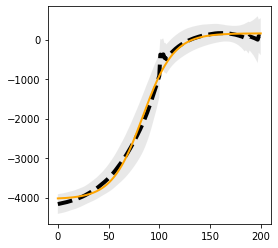

In [10]:
from deepskin.geometry import shape_edge
from scipy.optimize import curve_fit

def sigmoid(x, L, x0, k, b):
  '''
  L is responsible for scaling the 
    output range from [0, 1] to [0, L]
  x0 is the point in the middle of the Sigmoid, 
    i.e. the point where Sigmoid should originally 
    output the value 1/2 
    [since if x=x0, we get 1/(1+exp(0)) = 1/2]
  k is responsible for scaling the input, 
    which remains in (-inf, inf)
  b adds bias to the output and changes 
    its range from [0, L] to [b, L+b]    
  '''
  y = L / (1 + np.exp(-k*(x-x0))) + b
  return (y)

# get the "detph-signal" information directly from
# the deepskin function
mean, std = shape_edge(
  mask=wound_mask,
  depth=depth_corrected,
  iterations=iterations
)

# fit the trend with a sigmoid function
xdata = np.arange(len(mean))[:]
ydata = mean[:]

# this is an mandatory initial guess
p0 = [min(ydata), np.median(xdata), 1, max(ydata)]
popt, pcov = curve_fit(
  sigmoid, 
  xdata, ydata, 
  p0, 
  method='dogbox',
)
L, x0, k, b = popt

# generate the fit curve
xfit = np.linspace(xdata.min(), xdata.max(), 1000)
yfit = sigmoid(xfit, *popt)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
_ = ax.fill_between(
  range(len(mean)), 
  mean+std, mean-std, 
  facecolor='lightgray', 
  alpha=0.5
)
_ = ax.plot(
  range(len(mean)), mean, 
  linestyle='dashed',
  color='k',
  linewidth=4
)
_ = ax.plot(
  xfit, yfit, 
  color='orange',
  linewidth=2
)

At the same time, if you are interested into a fully 3D reconstruction of the wound depth, starting from the obtained information (and their intermediate corrections!), you can directly visualize the shapes for other kind of characterizations (es. wound volume).

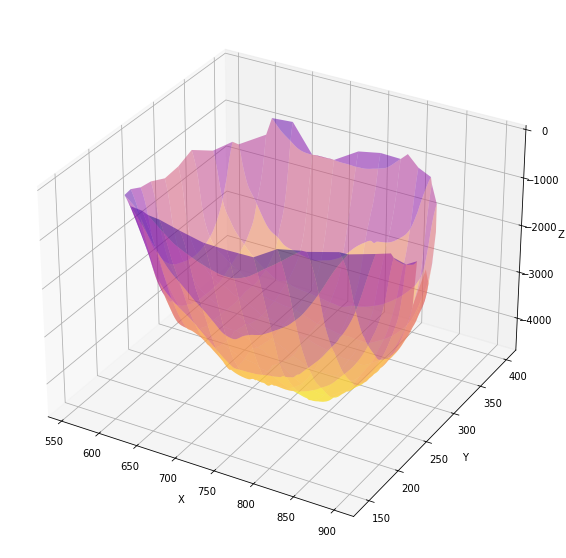

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# create a new grid for the curvature correction
h, w = depth_corrected.shape
y, x = np.mgrid[0:h, 0:w]

# get the depth map (corrected) inside the wound
depth_wound_corrected = np.where(
  wound_mask != 0, 
  depth_corrected, 
  np.nan
)
x = np.where(
  wound_mask != 0,
  x,
  np.nan
)
y = np.where(
  wound_mask != 0,
  y,
  np.nan
)

fig = plt.figure(figsize=(10, 10)) 
ax = fig.add_subplot(111, projection='3d') 
ax.plot_surface(x, y, depth_wound_corrected, cmap='plasma_r', alpha=0.5) 
ax.set_xlabel('X') 
ax.set_ylabel('Y') 
ax.set_zlabel('Z') 
plt.show()